Parkinson’s Disease (PD) is a degenerative neurological disorder marked by decreased dopamine levels in the brain. It manifests itself through a deterioration of movement, including the presence of tremors and stiffness. There is commonly a marked effect on speech, including dysarthria (difficulty articulating sounds), hypophonia (lowered volume), and monotone (reduced pitch range). Additionally, cognitive impairments and changes in mood can occur, and risk of dementia is increased.

Traditional diagnosis of Parkinson’s Disease involves a clinician taking a neurological history of the patient and observing motor skills in various situations. Since there is no definitive laboratory test to diagnose PD, diagnosis is often difficult, particularly in the early stages when motor effects are not yet severe. Monitoring progression of the disease over time requires repeated clinic visits by the patient. An effective screening process, particularly one that doesn’t require a clinic visit, would be beneficial. Since PD patients exhibit characteristic vocal features, voice recordings are a useful and non-invasive tool for diagnosis. If machine learning algorithms could be applied to a voice recording dataset to accurately diagnosis PD, this would be an effective screening step prior to an appointment with a clinician.

The data & attributes information for this project is available at https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/ (Links to an external site.)Links to an external site. The data consists of those diagnosed with Parkinson Disease and those who do not.

#### Steps to be followed:

1) Use a Python notebook & Load the dataset.  
2) It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)  

In [208]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn import metrics
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [221]:
park_df = pd.read_csv("parkinsons.data")
park_df.head(3).T

,0,1,2
name,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3
MDVP:Fo(Hz),119.992,122.4,116.682
MDVP:Fhi(Hz),157.302,148.65,131.111
MDVP:Flo(Hz),74.997,113.819,111.555
MDVP:Jitter(%),0.00784,0.00968,0.0105
MDVP:Jitter(Abs),7e-05,8e-05,9e-05
MDVP:RAP,0.0037,0.00465,0.00544
MDVP:PPQ,0.00554,0.00696,0.00781
Jitter:DDP,0.01109,0.01394,0.01633
MDVP:Shimmer,0.04374,0.06134,0.05233


In [222]:
park_df.shape

(195, 24)

In [211]:
park_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [212]:
park_df["name"].unique

<bound method Series.unique of 0      phon_R01_S01_1
1      phon_R01_S01_2
2      phon_R01_S01_3
3      phon_R01_S01_4
4      phon_R01_S01_5
5      phon_R01_S01_6
6      phon_R01_S02_1
7      phon_R01_S02_2
8      phon_R01_S02_3
9      phon_R01_S02_4
10     phon_R01_S02_5
11     phon_R01_S02_6
12     phon_R01_S04_1
13     phon_R01_S04_2
14     phon_R01_S04_3
15     phon_R01_S04_4
16     phon_R01_S04_5
17     phon_R01_S04_6
18     phon_R01_S05_1
19     phon_R01_S05_2
20     phon_R01_S05_3
21     phon_R01_S05_4
22     phon_R01_S05_5
23     phon_R01_S05_6
24     phon_R01_S06_1
25     phon_R01_S06_2
26     phon_R01_S06_3
27     phon_R01_S06_4
28     phon_R01_S06_5
29     phon_R01_S06_6
            ...      
165    phon_R01_S42_1
166    phon_R01_S42_2
167    phon_R01_S42_3
168    phon_R01_S42_4
169    phon_R01_S42_5
170    phon_R01_S42_6
171    phon_R01_S43_1
172    phon_R01_S43_2
173    phon_R01_S43_3
174    phon_R01_S43_4
175    phon_R01_S43_5
176    phon_R01_S43_6
177    phon_R01_S44_1
1

In [223]:
park_df.set_index('name',inplace=True)

In [214]:
park_df.head(5)

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
name,,,,,,,,,,,,,,,,,,,,,
phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


#### Ans 
Here "status" is the output variable.
"name" can be made index as this is a unique variable 

#### 3) Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)

#### Ans)    
First let me check the Correlation between the variables and will perform VIF to remove highly correlated variables.

In [224]:
park_df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383535,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.166136,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.380200,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.278220,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.338653,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.266668,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.288698,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.266646,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.367430,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.350697,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058


Even though Decision Trees and Random Forest donot require VIF method to be performed, but still it is no use having highly correlated data in the dataframe. From the above correlation matrix we can remove the below columns :     
MDVP:Jitter(Abs)  
MDVP:RAP  
MDVP:PPQ    
Jitter:DDP	  
NHR  
Shimmer:APQ3  
Shimmer:APQ5	  
MDVP:Shimmer(dB)	  
MDVP:Shimmer	  
spread1  

In [227]:
park_df.drop(["MDVP:Jitter(Abs)","MDVP:RAP","MDVP:PPQ","Jitter:DDP","NHR","Shimmer:APQ3","Shimmer:APQ5","MDVP:Shimmer(dB)","MDVP:Shimmer","spread1"],axis=1,inplace=True)

In [228]:
park_df.shape

(195, 13)

In [230]:
X =  park_df.drop("status", axis=1)
y =  park_df.pop("status")

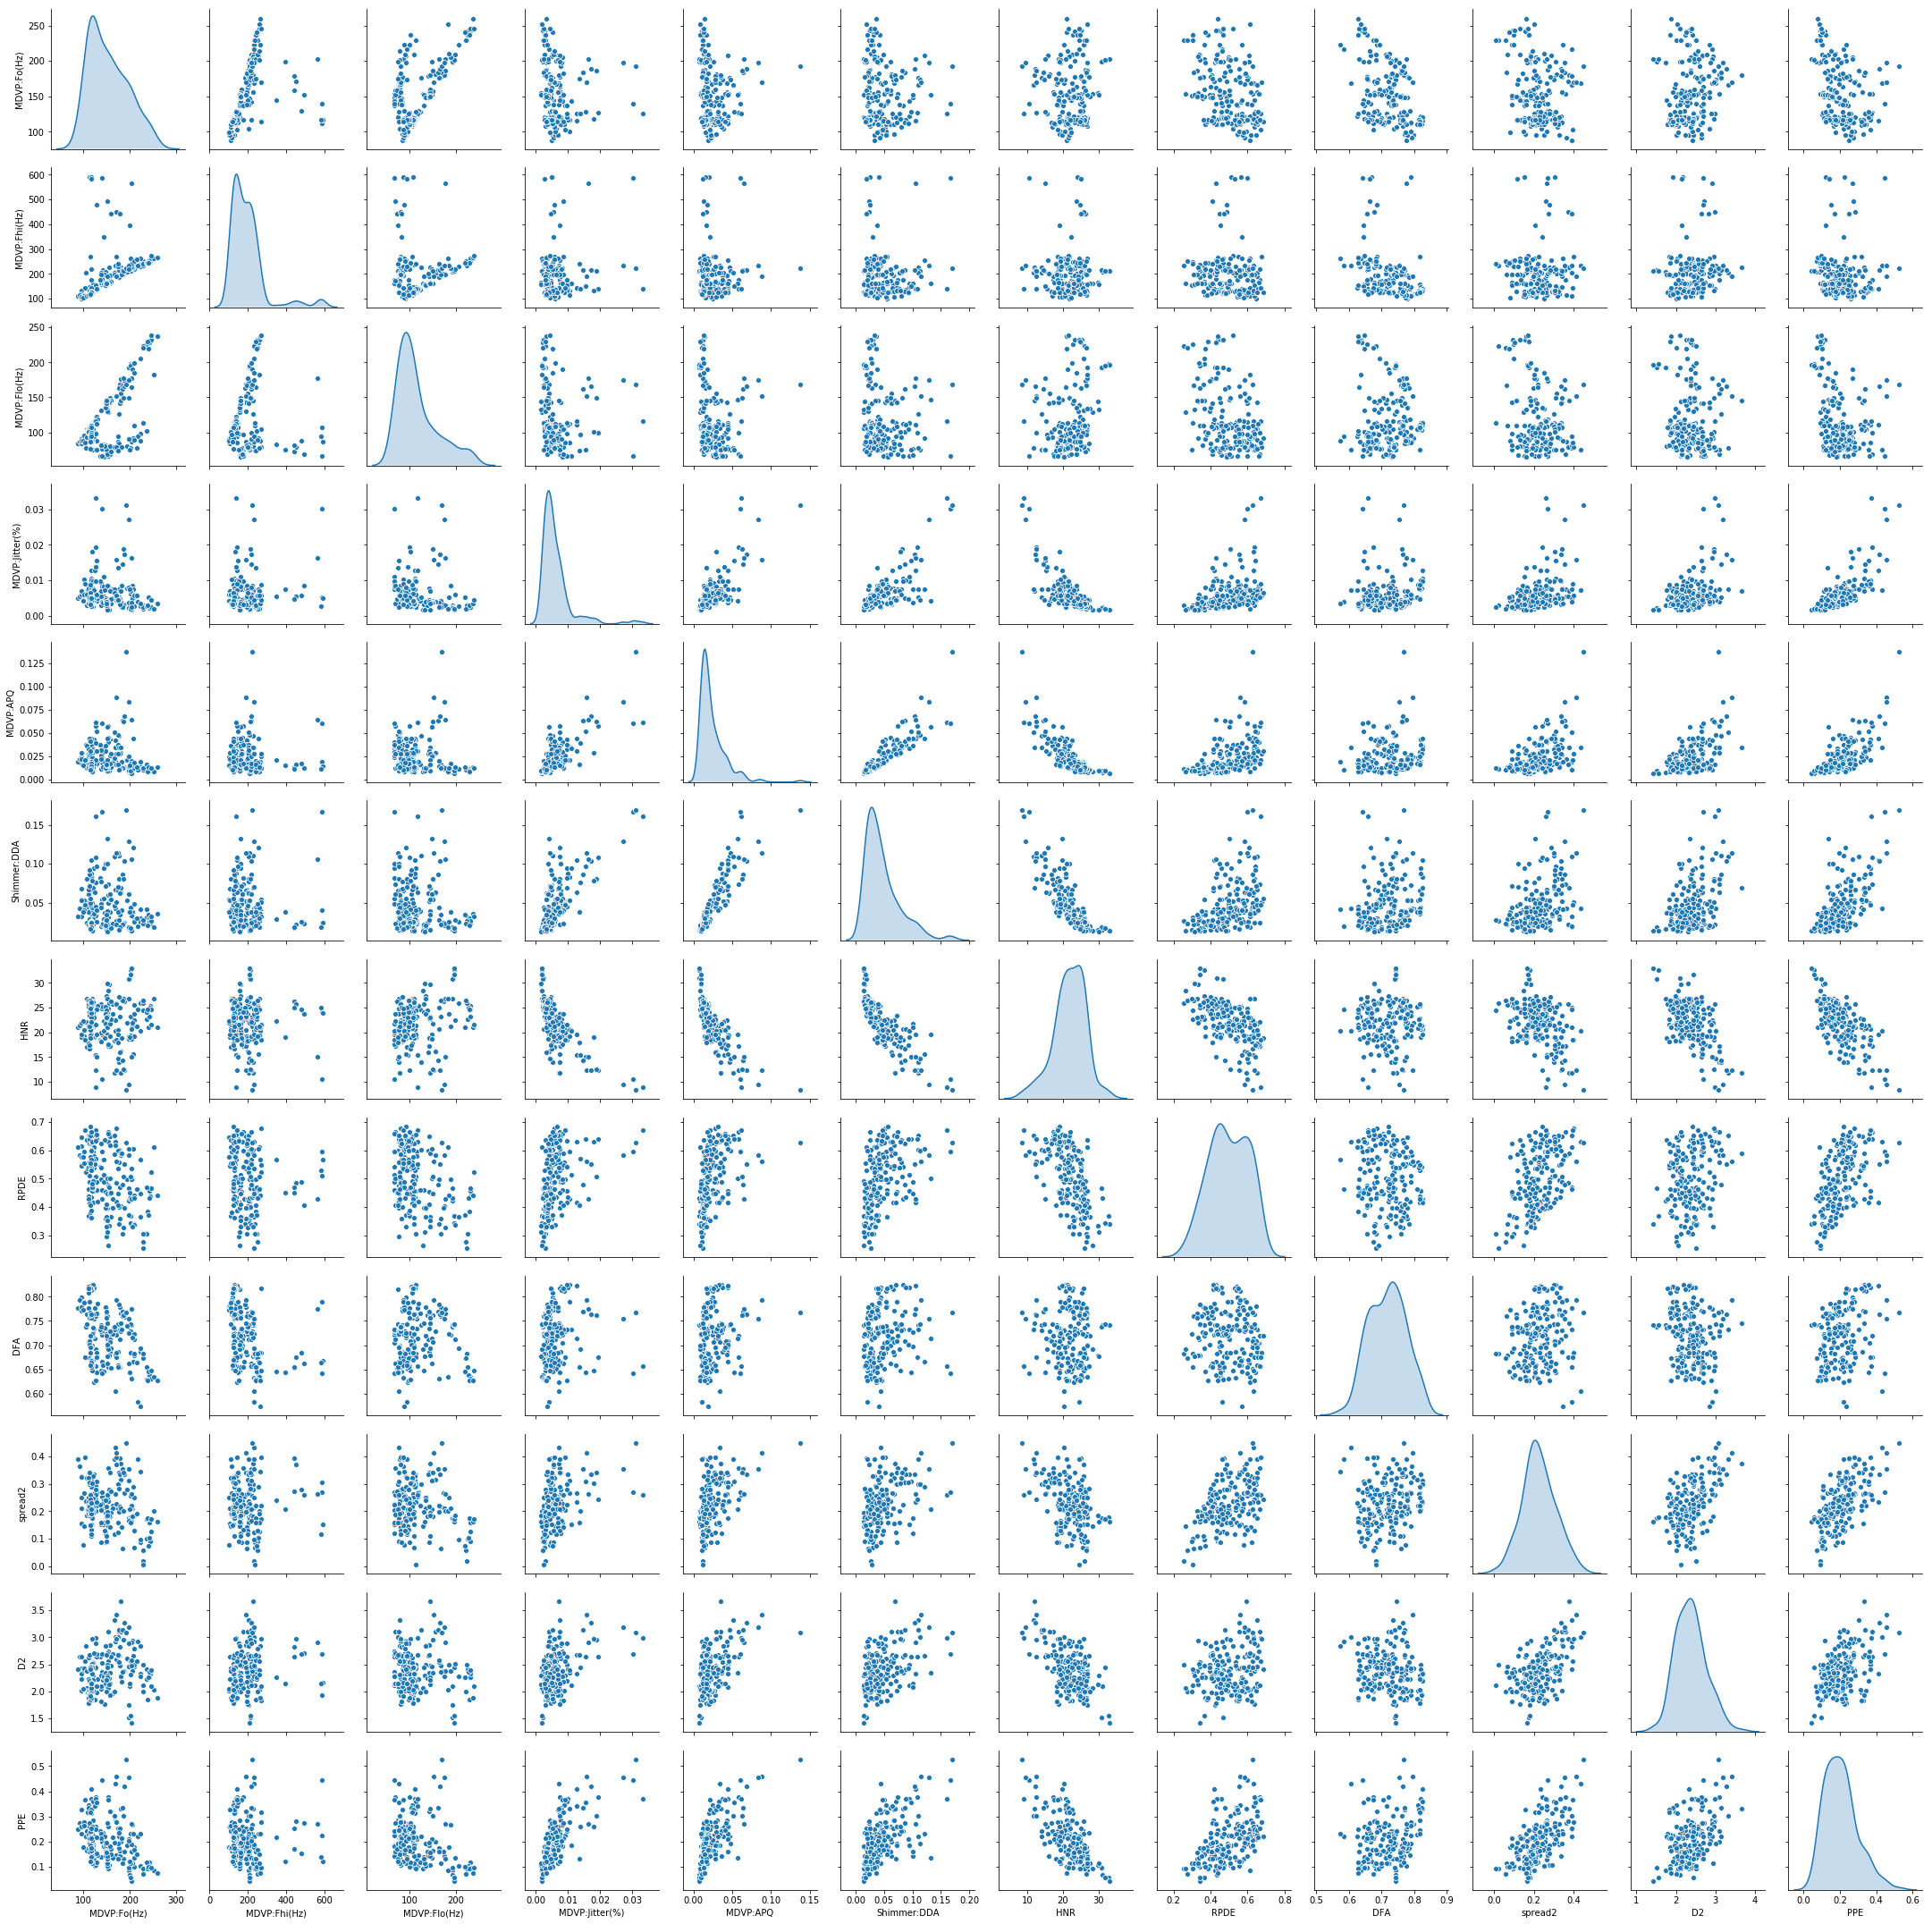

In [231]:
import seaborn as sns
sns.pairplot(X,diag_kind='kde')

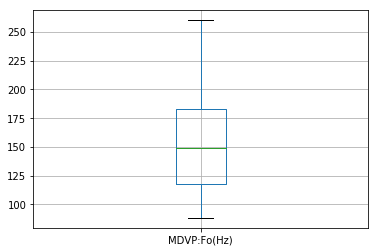

In [238]:
X.boxplot(column=["MDVP:Fo(Hz)"])

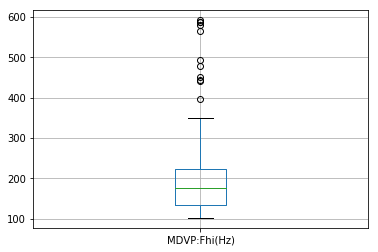

In [237]:
X.boxplot(column=["MDVP:Fhi(Hz)"])

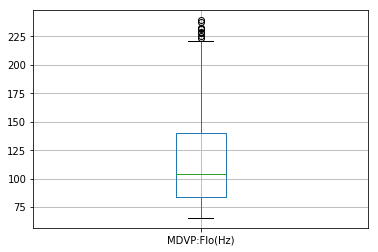

In [240]:
X.boxplot(column=["MDVP:Flo(Hz)"])

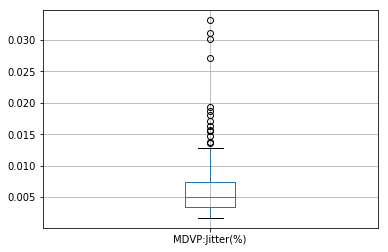

In [241]:
X.boxplot(column=["MDVP:Jitter(%)"])

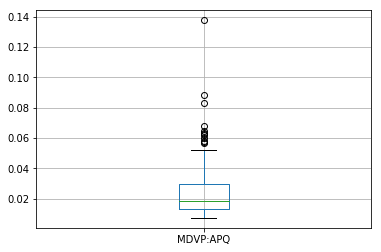

In [242]:
X.boxplot(column=["MDVP:APQ"])

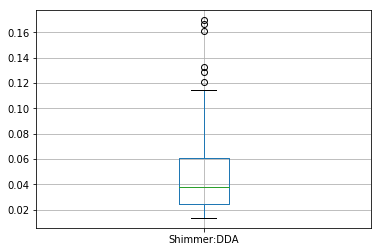

In [243]:
X.boxplot(column=["Shimmer:DDA"])

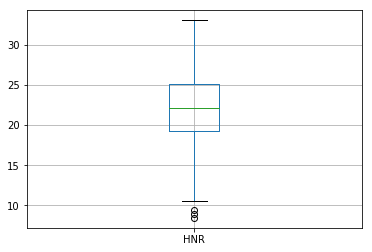

In [244]:
X.boxplot(column=["HNR"])

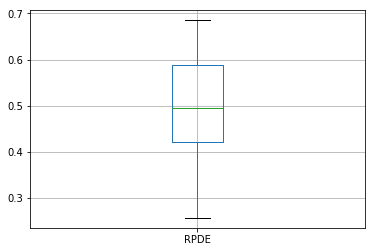

In [245]:
X.boxplot(column=["RPDE"])

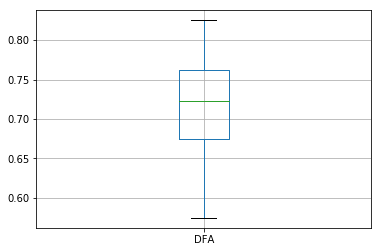

In [246]:
X.boxplot(column=["DFA"])

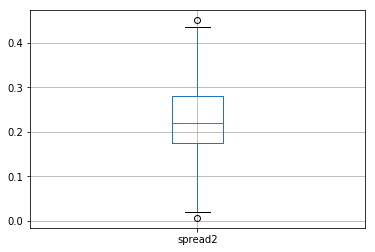

In [247]:
X.boxplot(column=["spread2"])

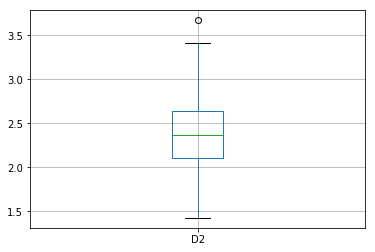

In [248]:
X.boxplot(column=["D2"])

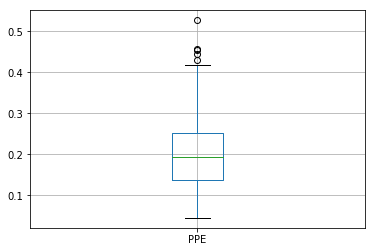

In [249]:
X.boxplot(column=["PPE"])

Column : MDVP:Fhi(Hz), MDVP:Jitter(%), MDVP:APQ, Shimmer:DDA has outliers.    
But Decision Tree is Robust to Outliers.

4) Split the dataset into training and test set in the ratio of 70:30 (Training:Test).

In [276]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

5) Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)

In [277]:
model=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

6) Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)

In [278]:
ypred=model.predict(X_test)

In [279]:
acc=metrics.accuracy_score(y_test,ypred)
print(acc)

0.8813559322033898


7) Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points) 

In [281]:
model1=DecisionTreeClassifier(max_depth=3,criterion='entropy',random_state=0,min_samples_leaf=2)
model1.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=3,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=2, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [282]:
ypred1=model1.predict(X_test)

In [283]:
acc=metrics.accuracy_score(y_test,ypred1)
print(acc)

0.864406779661017


In [288]:
model2=DecisionTreeClassifier(max_depth=6,criterion='entropy',random_state=0,min_samples_leaf=2)
model2.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=6,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=2, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [289]:
ypred2=model2.predict(X_test)

In [290]:
acc=metrics.accuracy_score(y_test,ypred2)
print(acc)

0.8813559322033898


#### If we regularise the model  by decreasing the max Depth, the accuracy is decerased.
On the other hand even if we increase the depth of the tree, there is no effect on accuracy.   
max_depth=4 seems to be appropriate depth for the model.

8) Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)

In [291]:
#Bootstrapped sampled multiple decision tree(with the hope of controlling bias error)
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',max_depth=4,random_state=0 )

In [293]:
Rf_model.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=51, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

In [297]:
y_predict_Rf=Rf_model.predict(X_test)

In [299]:
Rf_cr=metrics.classification_report(y_test , y_predict_Rf)
print(Rf_cr)

              precision    recall  f1-score   support

           0       0.89      0.67      0.76        12
           1       0.92      0.98      0.95        47

   micro avg       0.92      0.92      0.92        59
   macro avg       0.90      0.82      0.86        59
weighted avg       0.91      0.92      0.91        59

